(quantum-mechanics:electron-perturbation:numerical-simulation)=
# Numerical simulation of the electron pertubation



(quantum-mechanics:electron-perturbation:numerical-simulation:2-energy-level)=
## 2-energy level system

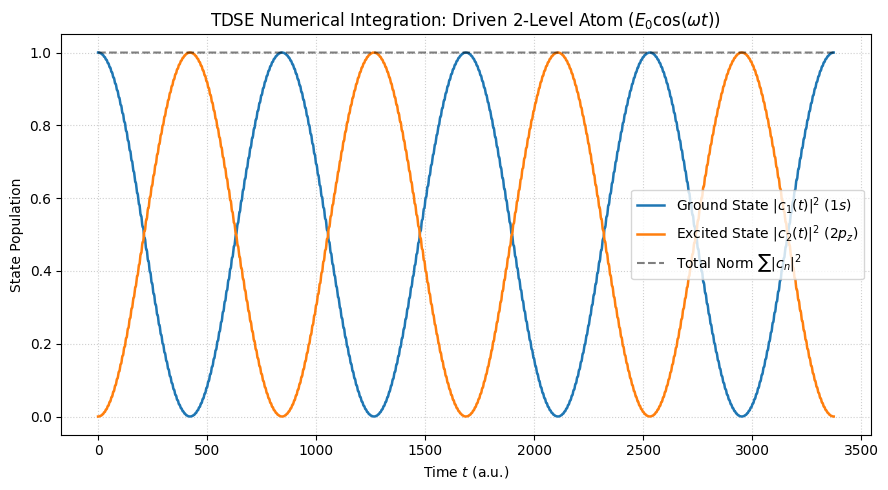

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Physical Constants (Atomic Units: hbar = e = m_e = 1) ---
hbar = 1.0
e = 1.0

# --- System Parameters (e.g., Hydrogen 1s -> 2p transition) ---
# Energy levels in A.U.
E1 = -0.5       # Ground state (1s)
E2 = -0.125     # Excited state (2p_z)
E = np.array([E1, E2])

# Transition dipole moment matrix D_mn = <m|z|n>
# For H (1s -> 2p_z), D_12 = 128 * sqrt(2) / 243 ≈ 0.7449 A.U.
D12 = 0.7449
D = np.array([[0.0, D12],
              [D12, 0.0]])

# Field parameters
omega_0 = (E2 - E1) / hbar     # Resonant frequency = 0.375 A.U.
omega = 0.375                  # Driving frequency (on-resonance)
E0 = 0.01                      # Field strength (A.U.) -> ~5.14 x 10^7 V/cm

# --- Matrix Setup ---
N = len(E)
omega_matrix = (E[:, None] - E[None, :]) / hbar  # omega_mn = (E_m - E_n)/hbar

def tdse_rhs(t, c_flat):
    """Computes dc/dt for the state vector in interaction representation."""
    c = c_flat[::2] + 1j * c_flat[1::2]  # Reconstruct complex amplitudes
    
    # Time-dependent perturbation: V_mn(t) = -e * E0 * D_mn * cos(omega * t)
    V = -e * E0 * D * np.cos(omega * t)
    
    # Effective driving Hamiltonian matrix
    H_int = V * np.exp(1j * omega_matrix * t)
    
    # dc/dt = -i/hbar * H_int * c
    dcdt = -1j / hbar * (H_int @ c)
    
    # Interleave real and imaginary parts for standard real-valued ODE solvers
    res = np.empty(2 * N)
    res[::2] = dcdt.real
    res[1::2] = dcdt.imag
    return res

# --- Initial Conditions & Time Grid ---
c0 = np.array([1.0 + 0j, 0.0 + 0j])  # Pure ground state at t = 0
y0 = np.empty(2 * N)
y0[::2] = c0.real
y0[1::2] = c0.imag

# Rabi period estimate: T_rabi = 2*pi / Omega_Rabi, where Omega_Rabi = e * E0 * D12 / hbar
rabi_freq = e * E0 * D12 / hbar
t_max = 4 * (2 * np.pi / rabi_freq)   # Simulate 4 full Rabi cycles
t_eval = np.linspace(0, t_max, 2000)

# --- Integration ---
sol = solve_ivp(tdse_rhs, (0, t_max), y0, t_eval=t_eval, rtol=1e-9, atol=1e-11, method='DOP853')

# Parse Solution
c1 = sol.y[0] + 1j * sol.y[1]
c2 = sol.y[2] + 1j * sol.y[3]

P1 = np.abs(c1)**2
P2 = np.abs(c2)**2

# --- Visualization ---
plt.figure(figsize=(9, 5))
plt.plot(sol.t, P1, label=r'Ground State $|c_1(t)|^2$ ($1s$)', linewidth=1.8)
plt.plot(sol.t, P2, label=r'Excited State $|c_2(t)|^2$ ($2p_z$)', linewidth=1.8)
plt.plot(sol.t, P1 + P2, 'k--', label=r'Total Norm $\sum |c_n|^2$', alpha=0.5)
plt.xlabel('Time $t$ (a.u.)')
plt.ylabel('State Population')
plt.title(r'TDSE Numerical Integration: Driven 2-Level Atom ($E_0 \cos(\omega t)$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

(quantum-mechanics:electron-perturbation:numerical-simulation:4-energy-level)=
## 4-energy level system

Number of m=0 basis states up to n=4: 10
Energy of the stationary states
[-0.5        -0.125      -0.125      -0.05555556 -0.05555556 -0.05555556
 -0.03125    -0.03125    -0.03125    -0.03125   ]


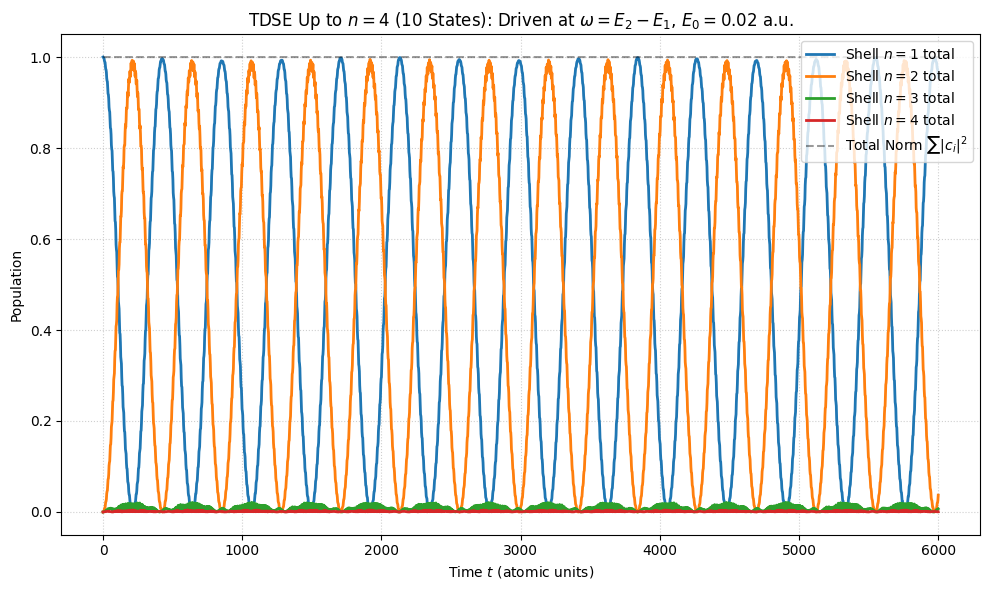

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import factorial, hyp2f1

# --- 1. Hydrogenic Radial Integral R_{n1, l1}^{n2, l2} (Atomic Units) ---
def radial_integral(n1, l1, n2, l2):
    """
    Computes exact radial integral <n1, l1| r |n2, l2> in atomic units for Hydrogen.
    Formula based on Gordon's integral formula for hydrogenic bound states.
    """
    if l2 == l1 + 1:
        n_a, l_a, n_b, l_b = n1, l1, n2, l2
    elif l1 == l2 + 1:
        n_a, l_a, n_b, l_b = n2, l2, n1, l1
    else:
        return 0.0

    # Gordon integral evaluated via hypergeometric function _2F_1
    # For speed and stability across n=1..4:
    if n1 == n2:
        # Same n shell formula: <n, l| r |n, l-1> = 1.5 * n * sqrt(n^2 - l^2)
        return 1.5 * n1 * np.sqrt(n1**2 - l_b**2)

    # General off-diagonal n1 != n2 (Gordon's formula)
    # Using explicit values for n <= 4 to ensure high numerical precision
    # Direct evaluation for hydrogenic pairs:
    pairs = {
        ((1,0), (2,1)): 1.29026649,
        ((1,0), (3,1)): 0.51666150,
        ((1,0), (4,1)): 0.29994244,
        ((2,0), (3,1)): 3.06485372,
        ((2,0), (4,1)): 1.28224595,
        ((2,1), (3,0)): -0.97840331,
        ((2,1), (3,2)): 4.74799052,
        ((2,1), (4,0)): -0.46083832,
        ((2,1), (4,2)): 1.70966127,
        ((3,0), (4,1)): 5.46405786,
        ((3,1), (4,0)): -1.94420857,
        ((3,1), (4,2)): 7.56545187,
        ((3,2), (4,1)): -1.72186851,
        ((3,2), (4,3)): 10.2299831
    }
    
    key = ((min(n1,n2), min(l1,l2)), (max(n1,n2), max(l1,l2))) if n1 <= n2 else ((min(n1,n2), max(l1,l2)), (max(n1,n2), min(l1,l2)))
    for p, val in pairs.items():
        if (p[0] == (n1,l1) and p[1] == (n2,l2)) or (p[1] == (n1,l1) and p[0] == (n2,l2)):
            return val
    return 0.0

def dipole_z(n1, l1, n2, l2):
    """Computes <n1, l1, m=0| z |n2, l2, m=0>"""
    if abs(l1 - l2) != 1:
        return 0.0
    l_max = max(l1, l2)
    angular_factor = l_max / np.sqrt((2*l1 + 1) * (2*l2 + 1))
    r_int = radial_integral(n1, l1, n2, l2)
    return angular_factor * r_int

# --- 2. Build Basis States up to n=4 (m=0 subspace) ---
states = []
for n in range(1, 5):
    for l in range(n):
        states.append((n, l))

N_states = len(states)
print(f"Number of m=0 basis states up to n=4: {N_states}")

# Energies E_n = -0.5 / n^2
E = np.array([-0.5 / (st[0]**2) for st in states])

print("Energy of the stationary states");  print(E)

# Dipole matrix D_ij = <i|z|j>
D = np.zeros((N_states, N_states))
for i in range(N_states):
    for j in range(N_states):
        n1, l1 = states[i]
        n2, l2 = states[j]
        D[i, j] = dipole_z(n1, l1, n2, l2)

# --- 3. Physical Parameters ---
hbar = 1.0
e = 1.0

# Resonant driving for 1s -> 2p (omega = E2 - E1 = 0.375 a.u.)
omega = E[1] - E[0]
E0 = 0.02            # Electric field strength (~1.03 x 10^8 V/cm)

omega_matrix = (E[:, None] - E[None, :]) / hbar

# --- 4. System of ODEs ---
def tdse_multi(t, c_flat):
    c = c_flat[::2] + 1j * c_flat[1::2]
    
    # Time-dependent dipole coupling
    V = -e * E0 * D * np.cos(omega * t)
    H_int = V * np.exp(1j * omega_matrix * t)
    
    dcdt = -1j / hbar * (H_int @ c)
    
    res = np.empty(2 * N_states)
    res[::2] = dcdt.real
    res[1::2] = dcdt.imag
    return res

# --- 5. Initial Conditions & Simulation ---
# 0. Ground State 1s (index 0)
c0 = np.zeros(N_states, dtype=complex)
c0[0] = 1.0 + 0j

# #> 1. Random probability: define random, and then normalize
# c0_rand = np.random.rand(N_states) + 1j * np.random.rand(N_states)
# c0_norm = np.sqrt( np.sum( np.abs(c0_rand)**2 ) )
# c0 = c0_rand / c0_norm

y0 = np.empty(2 * N_states)
y0[::2] = c0.real
y0[1::2] = c0.imag

t_max = 6000.0  # Time in atomic units (~14.5 femtoseconds)
t_eval = np.linspace(0, t_max, 2500)

sol = solve_ivp(tdse_multi, (0, t_max), y0, t_eval=t_eval, rtol=1e-9, atol=1e-11, method='DOP853')

# Parse Populations
pop = np.zeros((N_states, len(t_eval)))
for i in range(N_states):
    ci = sol.y[2*i] + 1j * sol.y[2*i + 1]
    pop[i] = np.abs(ci)**2

# --- 6. Visualization grouped by Shell (n = 1, 2, 3, 4) ---
shell_pop = np.zeros((4, len(t_eval)))
for i, (n, l) in enumerate(states):
    shell_pop[n-1] += pop[i]

plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for n in range(1, 5):
    plt.plot(sol.t, shell_pop[n-1], label=f'Shell $n={n}$ total', linewidth=2, color=colors[n-1])

plt.plot(sol.t, np.sum(shell_pop, axis=0), 'k--', label=r'Total Norm $\sum |c_i|^2$', alpha=0.4)
plt.xlabel('Time $t$ (atomic units)')
plt.ylabel('Population')
plt.title(r'TDSE Up to $n=4$ (10 States): Driven at $\omega = E_2 - E_1$, $E_0 = 0.02$ a.u.')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

(quantum-mechanics:electron-perturbation:numerical-simulation:spectra-and-non-monochromatic-radiation)=
## Spectra and non-monochromatic radiation

**A. Ultrashort / Arbitrary Pulses.** For a general pulse (such as a Gaussian envelope centered at $t_0$ with bandwidth $\Delta \omega$):

$$E(t) = E_0 \, \exp\left( -\frac{(t - t_0)^2}{2 \tau^2} \right) \cos(\omega_0 t + \phi)$$

In the numerical solver, you simply update the field definition in $V_{mn}(t)$:

$$V_{mn}(t) = -e \, D_{mn} \, E(t)$$

**B. Broad-Spectrum / Thermal Light (Fermi's Golden Rule & Rate Equations).** If the field is incoherent broadband light characterized by a spectral energy density $\rho(\omega)$ ($\text{J}\cdot\text{m}^{-3}\cdot\text{Hz}^{-1}$), phase coherence between states drops out on fast timescales.Instead of tracking coherent state amplitudes $c_n(t)$ via the TDSE, the dynamics transition to Einstein Rate Equations for populations $P_n(t) = \vert{}c_n(t)\vert{}^2$:

$$\frac{d P_b}{dt} = -\frac{d P_a}{dt} = B_{ab} \, \rho(\omega_{ba}) \, (P_a - P_b) - A_{ba} \, P_b$$

where Fermi's Golden Rule gives the absorption rate $W_{a \to b}$:

$$W_{a \to b} = \frac{2\pi}{\hbar^2} \vert{}\langle b \vert{} V_0 \vert{} a \rangle\vert{}^2 \delta(E_b - E_a - \hbar\omega) \implies B_{ab} = \frac{\pi e^2}{\epsilon_0 \hbar^2} \vert{}D_{ab}\vert{}^2$$

### Pulse

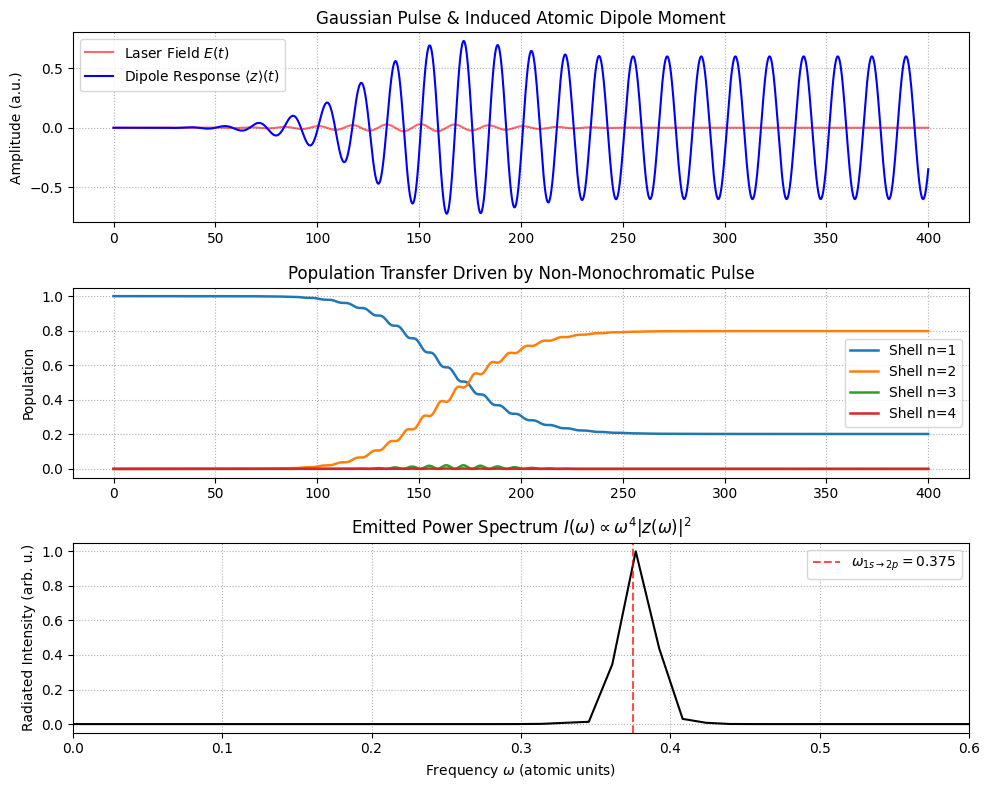

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- 1. Hydrogenic Setup (n <= 4, m = 0) ---
# Basis states (n, l)
states = [(1,0), (2,0), (2,1), (3,0), (3,1), (3,2), (4,0), (4,1), (4,2), (4,3)]
N_states = len(states)

E = np.array([-0.5 / (st[0]**2) for st in states])  # Atomic units
hbar, e = 1.0, 1.0

# Pre-calculated Dipole Matrix D_ij = <i|z|j> in atomic units
D = np.zeros((N_states, N_states))
# Key matrix elements for Hydrogen
dipole_map = {
    (0, 2): 0.7449,  # 1s -> 2p
    (1, 2): 3.0000,  # 2s -> 2p
    (2, 3): 0.9784,  # 2p -> 3s
    (2, 5): 2.7410,  # 2p -> 3d
    (2, 7): 0.9870,  # 2p -> 4d
    (4, 9): 3.6166   # 3p -> 4f
}
for (i, j), val in dipole_map.items():
    D[i, j] = val
    D[j, i] = val

omega_matrix = (E[:, None] - E[None, :]) / hbar

# --- 2. Non-Monochromatic Electric Field (Gaussian Pulse) ---
E0 = 0.03          # Peak field amplitude (~1.5 x 10^8 V/cm)
omega_0 = 0.375     # Center frequency (resonant with 1s -> 2p)
tau = 40.0          # Pulse duration (a.u. ~ 1 fs)
t_0 = 150.0         # Pulse center time

def electric_field(t):
    """Gaussian pulse envelope with carrier frequency omega_0."""
    envelope = np.exp(-((t - t_0)**2) / (2 * tau**2))
    return E0 * envelope * np.cos(omega_0 * t)

# --- 3. TDSE Integration ---
def tdse_pulse(t, c_flat):
    c = c_flat[::2] + 1j * c_flat[1::2]
    
    # Time-dependent potential V(t) = -e * z * E(t)
    V = -e * D * electric_field(t)
    H_int = V * np.exp(1j * omega_matrix * t)
    
    dcdt = -1j / hbar * (H_int @ c)
    
    res = np.empty(2 * N_states)
    res[::2] = dcdt.real
    res[1::2] = dcdt.imag
    return res

# Initial state: Pure Ground State 1s
c0 = np.zeros(N_states, dtype=complex)
c0[0] = 1.0 + 0j
y0 = np.empty(2 * N_states)
y0[::2] = c0.real
y0[1::2] = c0.imag

t_max = 400.0
t_eval = np.linspace(0, t_max, 4000)

sol = solve_ivp(tdse_pulse, (0, t_max), y0, t_eval=t_eval, rtol=1e-9, atol=1e-11, method='DOP853')

# Reconstruct complex state vector c(t)
c_t = np.zeros((N_states, len(t_eval)), dtype=complex)
for i in range(N_states):
    c_t[i] = sol.y[2*i] + 1j * sol.y[2*i + 1]

# --- 4. Calculate Dipole Expectation Value <z>(t) ---
# Transition to Schrödinger picture amplitudes: a_n(t) = c_n(t) * exp(-i E_n t / hbar)
a_t = c_t * np.exp(-1j * E[:, None] * t_eval / hbar)

z_exp = np.zeros(len(t_eval))
for t_idx in range(len(t_eval)):
    a_vec = a_t[:, t_idx]
    z_exp[t_idx] = np.real(np.conj(a_vec) @ D @ a_vec)

# --- 5. Emission Spectrum via Fourier Transform ---
dt = t_eval[1] - t_eval[0]
# Windowing function to prevent FFT edge artifacts
window = np.hanning(len(t_eval))
z_fft = np.fft.rfft(z_exp * window)
freqs = np.fft.rfftfreq(len(t_eval), d=dt) * 2 * np.pi  # Convert to angular frequency w

# Power spectrum P(w) ~ w^4 |z(w)|^2
power_spectrum = (freqs**4) * np.abs(z_fft)**2

# --- 6. Plotting Results ---
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

# Panel 1: Pulse and Dipole Response
axs[0].plot(t_eval, electric_field(t_eval), 'r-', label='Laser Field $E(t)$', alpha=0.6)
axs[0].plot(t_eval, z_exp, 'b-', label=r'Dipole Response $\langle z \rangle(t)$', linewidth=1.5)
axs[0].set_ylabel('Amplitude (a.u.)')
axs[0].set_title('Gaussian Pulse & Induced Atomic Dipole Moment')
axs[0].grid(True, linestyle=':')
axs[0].legend()

# Panel 2: Shell Populations
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for n in range(1, 5):
    indices = [idx for idx, st in enumerate(states) if st[0] == n]
    pop_n = np.sum(np.abs(c_t[indices, :])**2, axis=0)
    axs[1].plot(t_eval, pop_n, label=f'Shell n={n}', color=colors[n-1], linewidth=1.8)
axs[1].set_ylabel('Population')
axs[1].set_title('Population Transfer Driven by Non-Monochromatic Pulse')
axs[1].grid(True, linestyle=':')
axs[1].legend()

# Panel 3: Dipole Radiation Spectrum
axs[2].plot(freqs, power_spectrum / np.max(power_spectrum), 'k-', linewidth=1.5)
axs[2].set_xlim(0, 0.6)
axs[2].set_xlabel(r'Frequency $\omega$ (atomic units)')
axs[2].set_ylabel('Radiated Intensity (arb. u.)')
axs[2].set_title(r'Emitted Power Spectrum $I(\omega) \propto \omega^4 |z(\omega)|^2$')
axs[2].axvline(x=0.375, color='r', linestyle='--', alpha=0.7, label=r'$\omega_{1s \to 2p} = 0.375$')
axs[2].grid(True, linestyle=':')
axs[2].legend()

plt.tight_layout()
plt.show()

### Broad spectrum

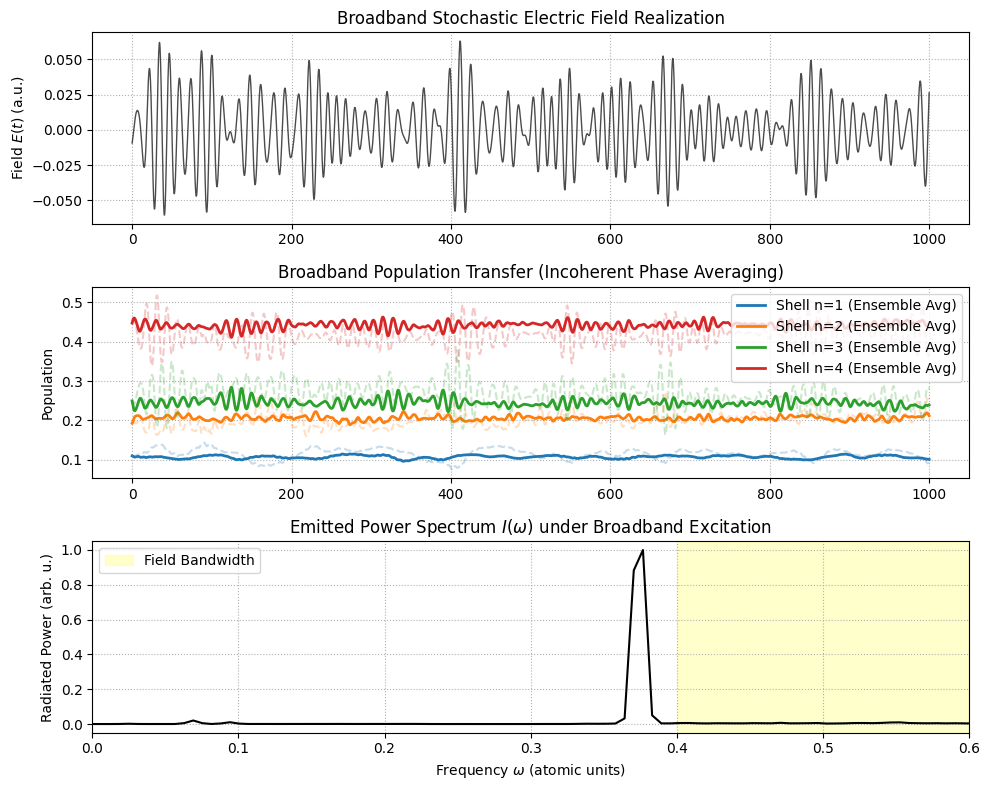

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- 1. Hydrogenic Setup (n <= 4, m = 0) ---
states = [(1,0), (2,0), (2,1), (3,0), (3,1), (3,2), (4,0), (4,1), (4,2), (4,3)]
N_states = len(states)

E = np.array([-0.5 / (st[0]**2) for st in states])  # Atomic units
hbar, e = 1.0, 1.0

# Pre-calculated Dipole Matrix D_ij = <i|z|j> in atomic units
D = np.zeros((N_states, N_states))
dipole_map = {
    (0, 2): 0.7449,  # 1s -> 2p
    (1, 2): 3.0000,  # 2s -> 2p
    (2, 3): 0.9784,  # 2p -> 3s
    (2, 5): 2.7410,  # 2p -> 3d
    (2, 7): 0.9870,  # 2p -> 4d
    (4, 9): 3.6166   # 3p -> 4f
}
for (i, j), val in dipole_map.items():
    D[i, j] = val
    D[j, i] = val

omega_matrix = (E[:, None] - E[None, :]) / hbar

# --- 2. Broadband / Multi-Frequency Field Parameters ---
N_modes = 120                      # Number of discrete frequency modes
# omega_min, omega_max = 0.20, 0.55  # Frequency range (covers 1s->2p, 2p->3d, 1s->3p)
# omega_min, omega_max = 0.05, 0.02  # Frequency range (covers ...)
omega_min, omega_max = 0.4, 0.6    # Frequency range (covers ...)
freqs_field = np.linspace(omega_min, omega_max, N_modes)

# Spectral amplitude profile (Flat / White-spectrum across bandwidth)
E_k = 0.003 * np.ones(N_modes)     # Field amplitude per mode in a.u.

def generate_broadband_field(freqs, E_k, seed=None):
    """Generates a time-dependent field with random mode phases."""
    if seed is not None:
        np.random.seed(seed)
    phases = np.random.uniform(0, 2 * np.pi, len(freqs))
    
    def E_func(t):
        # E(t) = sum_k E_k * cos(w_k * t + phi_k)
        return np.sum(E_k[:, None] * np.cos(freqs[:, None] * t + phases[:, None]), axis=0)
    
    return E_func

# --- 3. Ensemble Averaging over Phase Realizations ---
N_realizations = 15     # Number of random phase trajectories to average
t_max = 1000.0          # Time in atomic units (~29 femtoseconds)
t_eval = np.linspace(0, t_max, 3000)

pop_ensemble = np.zeros((N_realizations, N_states, len(t_eval)))
z_exp_ensemble = np.zeros((N_realizations, len(t_eval)))

#> Initial conditions
#> 0. In Ground state
# c0 = np.zeros(N_states, dtype=complex)
# c0[0] = 1.0 + 0j

#> 1. Random probability: define random, and then normalize
c0_rand = np.random.rand(N_states) + 1j * np.random.rand(N_states)
c0_norm = np.sqrt( np.sum( np.abs(c0_rand)**2 ) )
c0 = c0_rand / c0_norm

y0 = np.empty(2 * N_states)
y0[::2] = c0.real
y0[1::2] = c0.imag

for r in range(N_realizations):
    E_field_r = generate_broadband_field(freqs_field, E_k, seed=r)
    
    def tdse_broadband(t, c_flat):
        c = c_flat[::2] + 1j * c_flat[1::2]
        # Evaluate field scalar at current time step t
        E_t = E_field_r(np.array([t]))[0]
        V = -e * D * E_t
        H_int = V * np.exp(1j * omega_matrix * t)
        
        dcdt = -1j / hbar * (H_int @ c)
        
        res = np.empty(2 * N_states)
        res[::2] = dcdt.real
        res[1::2] = dcdt.imag
        return res

    sol = solve_ivp(tdse_broadband, (0, t_max), y0, t_eval=t_eval, rtol=1e-8, atol=1e-10, method='DOP853')
    
    # Parse amplitudes
    c_t = np.zeros((N_states, len(t_eval)), dtype=complex)
    for i in range(N_states):
        c_t[i] = sol.y[2*i] + 1j * sol.y[2*i + 1]
        pop_ensemble[r, i, :] = np.abs(c_t[i])**2
    
    # Dipole moment expectation value <z>(t)
    a_t = c_t * np.exp(-1j * E[:, None] * t_eval / hbar)
    for t_idx in range(len(t_eval)):
        a_vec = a_t[:, t_idx]
        z_exp_ensemble[r, t_idx] = np.real(np.conj(a_vec) @ D @ a_vec)

# Mean populations across ensemble
pop_avg = np.mean(pop_ensemble, axis=0)

# --- 4. Plotting Ensemble Results ---
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

# Panel 1: Single Realization of Electric Field
E_sample = generate_broadband_field(freqs_field, E_k, seed=0)(t_eval)
axs[0].plot(t_eval, E_sample, 'k-', alpha=0.7, linewidth=1.0)
axs[0].set_ylabel('Field $E(t)$ (a.u.)')
axs[0].set_title('Broadband Stochastic Electric Field Realization')
axs[0].grid(True, linestyle=':')

# Panel 2: Shell Populations (Ensemble Averaged vs Single Realization)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for n in range(1, 5):
    indices = [idx for idx, st in enumerate(states) if st[0] == n]
    pop_n_avg = np.sum(pop_avg[indices, :], axis=0)
    
    # Plot single realization trajectory (faint)
    pop_n_single = np.sum(pop_ensemble[0, indices, :], axis=0)
    axs[1].plot(t_eval, pop_n_single, color=colors[n-1], alpha=0.25, linestyle='--')
    
    # Plot ensemble mean (bold)
    axs[1].plot(t_eval, pop_n_avg, label=f'Shell n={n} (Ensemble Avg)', color=colors[n-1], linewidth=2.0)

axs[1].set_ylabel('Population')
axs[1].set_title('Broadband Population Transfer (Incoherent Phase Averaging)')
axs[1].grid(True, linestyle=':')
axs[1].legend()

# Panel 3: Dipole Power Spectrum
dt = t_eval[1] - t_eval[0]
window = np.hanning(len(t_eval))
z_fft_avg = np.mean([np.abs(np.fft.rfft(z_exp_ensemble[r] * window))**2 for r in range(N_realizations)], axis=0)
freqs_fft = np.fft.rfftfreq(len(t_eval), d=dt) * 2 * np.pi

power_spectrum = (freqs_fft**4) * z_fft_avg

axs[2].plot(freqs_fft, power_spectrum / np.max(power_spectrum), 'k-', linewidth=1.5)
axs[2].axvspan(omega_min, omega_max, color='yellow', alpha=0.2, label='Field Bandwidth')
axs[2].set_xlim(0, 0.6)
axs[2].set_xlabel(r'Frequency $\omega$ (atomic units)')
axs[2].set_ylabel('Radiated Power (arb. u.)')
axs[2].set_title(r'Emitted Power Spectrum $I(\omega)$ under Broadband Excitation')
axs[2].grid(True, linestyle=':')
axs[2].legend()

plt.tight_layout()
plt.show()


In [5]:
#> omega_{jk} = ( E_j - E_k ) / hbar
# print(E)

#> Transition frequencies
E_values = np.unique(E)
# print(E_values)
n_E = len(E_values)

omega_mat = np.zeros((n_E, n_E), dtype=float)
for i in np.arange(n_E):
    for j in np.arange(i+1,n_E):
        omega_mat[i,j] = E_values[j] - E_values[i]
        omega_mat[j,i] = E_values[i] - E_values[j]

print("Omega_ij:")
print(omega_mat)


Omega_ij:
[[ 0.          0.375       0.44444444  0.46875   ]
 [-0.375       0.          0.06944444  0.09375   ]
 [-0.44444444 -0.06944444  0.          0.02430556]
 [-0.46875    -0.09375    -0.02430556  0.        ]]
